In [123]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings("ignore")

# # 1. stop the automatic back to the ligne when display datasets
pd.set_option('display.expand_frame_repr', False)
# 2. display all columns
# pd.set_option('display.max_columns', None)



In [124]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

churn_df = pd.read_csv(url)
print(churn_df)

     tenure   age  address  income   ed  employ  equip  callcard  wireless  longmon  ...  pager  internet  callwait  confer  ebill  loglong  logtoll  lninc  custcat  churn
0      11.0  33.0      7.0   136.0  5.0     5.0    0.0       1.0       1.0     4.40  ...    1.0       0.0       1.0     1.0    0.0    1.482    3.033  4.913      4.0    1.0
1      33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0     9.45  ...    0.0       0.0       0.0     0.0    0.0    2.246    3.240  3.497      1.0    1.0
2      23.0  30.0      9.0    30.0  1.0     2.0    0.0       0.0       0.0     6.30  ...    0.0       0.0       0.0     1.0    0.0    1.841    3.240  3.401      3.0    0.0
3      38.0  35.0      5.0    76.0  2.0    10.0    1.0       1.0       1.0     6.05  ...    1.0       1.0       1.0     1.0    1.0    1.800    3.807  4.331      4.0    0.0
4       7.0  35.0     14.0    80.0  2.0    15.0    0.0       1.0       0.0     7.10  ...    0.0       0.0       1.0     1.0    0.0    1.960 

In [125]:

churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard','wireless','churn']]
churn_df['churn'] = churn_df['churn'].astype('int')

In [126]:
print(churn_df)

     tenure   age  address  income   ed  employ  equip  callcard  wireless  churn
0      11.0  33.0      7.0   136.0  5.0     5.0    0.0       1.0       1.0      1
1      33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0      1
2      23.0  30.0      9.0    30.0  1.0     2.0    0.0       0.0       0.0      0
3      38.0  35.0      5.0    76.0  2.0    10.0    1.0       1.0       1.0      0
4       7.0  35.0     14.0    80.0  2.0    15.0    0.0       1.0       0.0      0
..      ...   ...      ...     ...  ...     ...    ...       ...       ...    ...
195    55.0  44.0     24.0    83.0  1.0    23.0    0.0       1.0       0.0      0
196    34.0  23.0      3.0    24.0  1.0     7.0    0.0       1.0       0.0      0
197     6.0  32.0     10.0    47.0  1.0    10.0    0.0       1.0       0.0      0
198    24.0  30.0      0.0    25.0  4.0     5.0    0.0       1.0       1.0      1
199    61.0  50.0     16.0   190.0  2.0    22.0    1.0       1.0       1.0      0

[200 rows x 10 

In [127]:
X = np.array(churn_df[['tenure','age','address','income','ed','employ','equip','wireless','callcard']])
X[0:5] # exploration des 5 premiereres lignes des colonnnes des variables independantes


array([[ 11.,  33.,   7., 136.,   5.,   5.,   0.,   1.,   1.],
       [ 33.,  33.,  12.,  33.,   2.,   0.,   0.,   0.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.,   0.,   0.,   0.],
       [ 38.,  35.,   5.,  76.,   2.,  10.,   1.,   1.,   1.],
       [  7.,  35.,  14.,  80.,   2.,  15.,   0.,   0.,   1.]])

In [128]:
y = np.array(churn_df['churn'])
y[0:5]# exploration des 5 premiereres lignes de la colonne des variables dependantes

array([1, 1, 0, 0, 0])

In [129]:
X_norm = StandardScaler().fit(X).transform(X) # vu que les variables independentes sont plus grandes que la variable dependate, on normalize pourque ils soient sur la meme echelle que y

In [130]:
X_norm[0:5]


array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695,  1.56469673,  0.64686916],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695, -0.63910148, -1.54590766],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695, -0.63910148, -1.54590766],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ,  1.56469673,  0.64686916],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695, -0.63910148,  0.64686916]])

In [131]:
#Splitting the dataset 

In [132]:
X_train, X_test, y_train, y_test =  train_test_split(X_norm, y, test_size = 0.2, random_state = 42)



In [133]:
#Logistic regression classifier modeling

In [134]:
LR= LogisticRegression().fit(X_train, y_train)

In [135]:
yhat = LR.predict(X_test)
yhat[0:10]

array([0, 1, 0, 0, 0, 1, 0, 1, 1, 0])

In [136]:
yhat_proba = LR.predict_proba(X_test)
yhat_proba[:10]

array([[0.58236732, 0.41763268],
       [0.08907644, 0.91092356],
       [0.85051256, 0.14948744],
       [0.81222712, 0.18777288],
       [0.74775455, 0.25224545],
       [0.14058143, 0.85941857],
       [0.95446291, 0.04553709],
       [0.27953899, 0.72046101],
       [0.46167517, 0.53832483],
       [0.93621012, 0.06378988]])

In [137]:
# diagnostic  https://chatgpt.com/share/6a034d9c-81dc-83eb-8c09-45fa28b26000

In [138]:
for col, coef in zip (['tenure','age','address','income',
     'ed','employ','equip','callcard','wireless',],LR.coef_[0]):
    print(col,coef)

# LR.coef_[0] : ce sont les “forces” de chaque variable. Par exemple : callcard = -0.2436

tenure -0.5038392065125296
age -0.41987400537385344
address 0.2291869580397233
income 0.11333523470744854
ed 0.2701835293069775
employ -0.6088866131104327
equip 0.2351463808132768
callcard 0.5042890320457658
wireless -0.4359365782619561


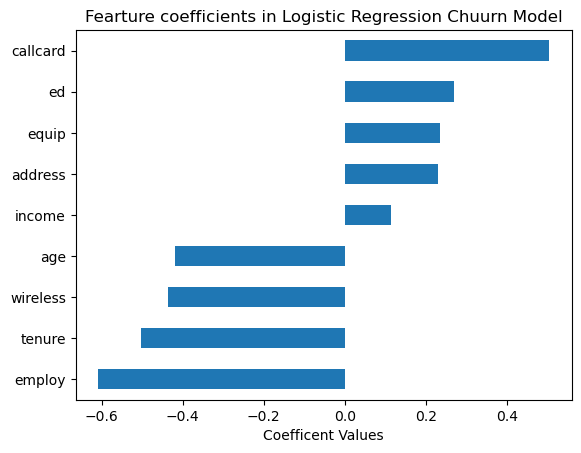

In [139]:
coefficients = pd.Series(LR.coef_[0], index = churn_df.columns[:-1])


coefficients.sort_values().plot(kind = 'barh')
plt.title("Fearture coefficients in Logistic Regression Chuurn Model")
plt.xlabel("Coefficent Values")
plt.show()